In [ ]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [ ]:
%config InlineBackend.figure_format = 'retina'

import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import SGDClassifier, SGDRegressor
from nsppk import NSPPK

from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator


In [ ]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 1000
min_num_nodes = 14
max_num_nodes = 16
USE_TARGETS = False

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
targets = [max(dict(graph.degree()).values(), default=0) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
if USE_TARGETS:
    print("target: max_degree")
else:
    print("targets disabled")


In [ ]:
feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(connected_component(), unlabel(), merge(use_edges=True), filter_by_edge_label(must_have_one_of=['aromatic']), edge()), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=2, distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

USE_SPARSE_LINEAR_MODE = True
vectorizer_kwargs = dict(radius=1, distance=4, connector=1, nbits=14, parallel=True)

graph_transformer = NSPPK(**vectorizer_kwargs, dense=not USE_SPARSE_LINEAR_MODE)
if USE_SPARSE_LINEAR_MODE:
    graph_estimator_model = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=0,
        class_weight="balanced",
    )
    target_estimator_model = SGDRegressor(
        loss="epsilon_insensitive",
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=0,
    )
    edge_risk_estimator_model = SGDRegressor(
        loss="epsilon_insensitive",
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=0,
    )
else:
    graph_estimator_model = RandomForestClassifier(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    target_estimator_model = RandomForestRegressor(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
    )
    edge_risk_estimator_model = RandomForestRegressor(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
    )

graph_estimator = GraphEstimator(
    transformer=graph_transformer,
    estimator=graph_estimator_model,
)

target_estimator = None
if USE_TARGETS:
    target_estimator = GraphEstimator(
        transformer=NSPPK(**vectorizer_kwargs, dense=not USE_SPARSE_LINEAR_MODE),
        estimator=target_estimator_model,
    )

edge_risk_estimator = GraphEstimator(
    transformer=NSPPK(**vectorizer_kwargs, dense=not USE_SPARSE_LINEAR_MODE),
    estimator=edge_risk_estimator_model,
)

generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=graph_estimator,
    target_estimator=target_estimator,
    edge_risk_estimator=edge_risk_estimator,
    target_estimator_mode="regression",
    decomposition_function=add(cycle(), tree()),
    enforce_diversity=False,
    n_negative_per_positive=5,
    n_replicates=5,
    beam_size=2,
    max_restarts=4,
    fit_n_jobs=-1,
    fit_backend="loky",
    edge_risk_lambda=0.25,
    verbose=True,
    seed=0,
)


In [ ]:
%%time
generator.store(graphs, targets=targets)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


graph_a_idx = 58
graph_b_idx = 663
pair_target = None


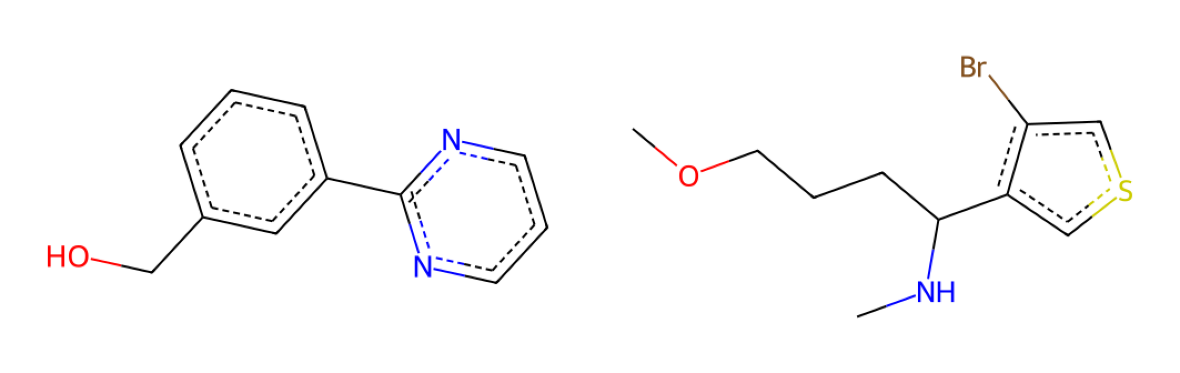

In [11]:
idx_a, idx_b = random.sample(range(len(graphs)), k=2)
graph_a = graphs[idx_a]
graph_b = graphs[idx_b]
pair_target = None
if USE_TARGETS:
    pair_target = int(round(np.mean([targets[idx_a], targets[idx_b]])))

print(f"graph_a_idx = {idx_a}")
print(f"graph_b_idx = {idx_b}")
print(f"pair_target = {pair_target}")
_ = display_graphs([graph_a, graph_b], n_graphs_per_line=2)


[pair] source_idx=58 dest_idx=663 n_paths=2 selected_graphs=36 path_k=7 path_lengths=[9, 12] training_set_time=0m 1.4s
[pair] selected_indices=[32, 35, 55, 58, 113, 168, 190, 234, 235, 240, 250, 265, 272, 290, 371, 405, 496, 510, 516, 593, 594, 621, 631, 663, 676, 702, 714, 772, 840, 841, 932, 935, 965, 984, 989, 999]
[pair] path 1/2 indices=[58, 965, 250, 621, 290, 984, 240, 631, 663]


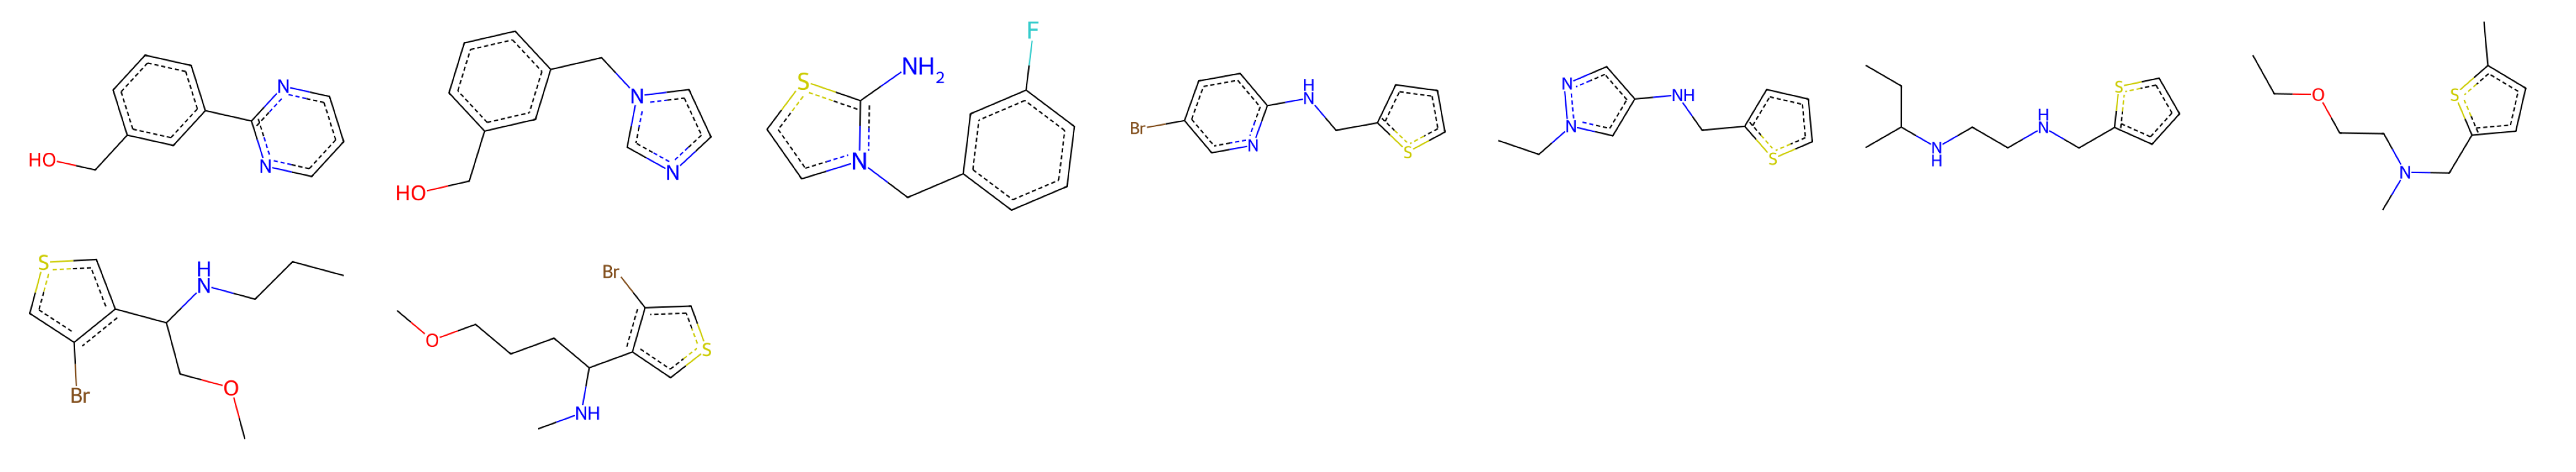

[pair] path 2/2 indices=[58, 272, 965, 55, 841, 168, 989, 593, 234, 265, 235, 663]


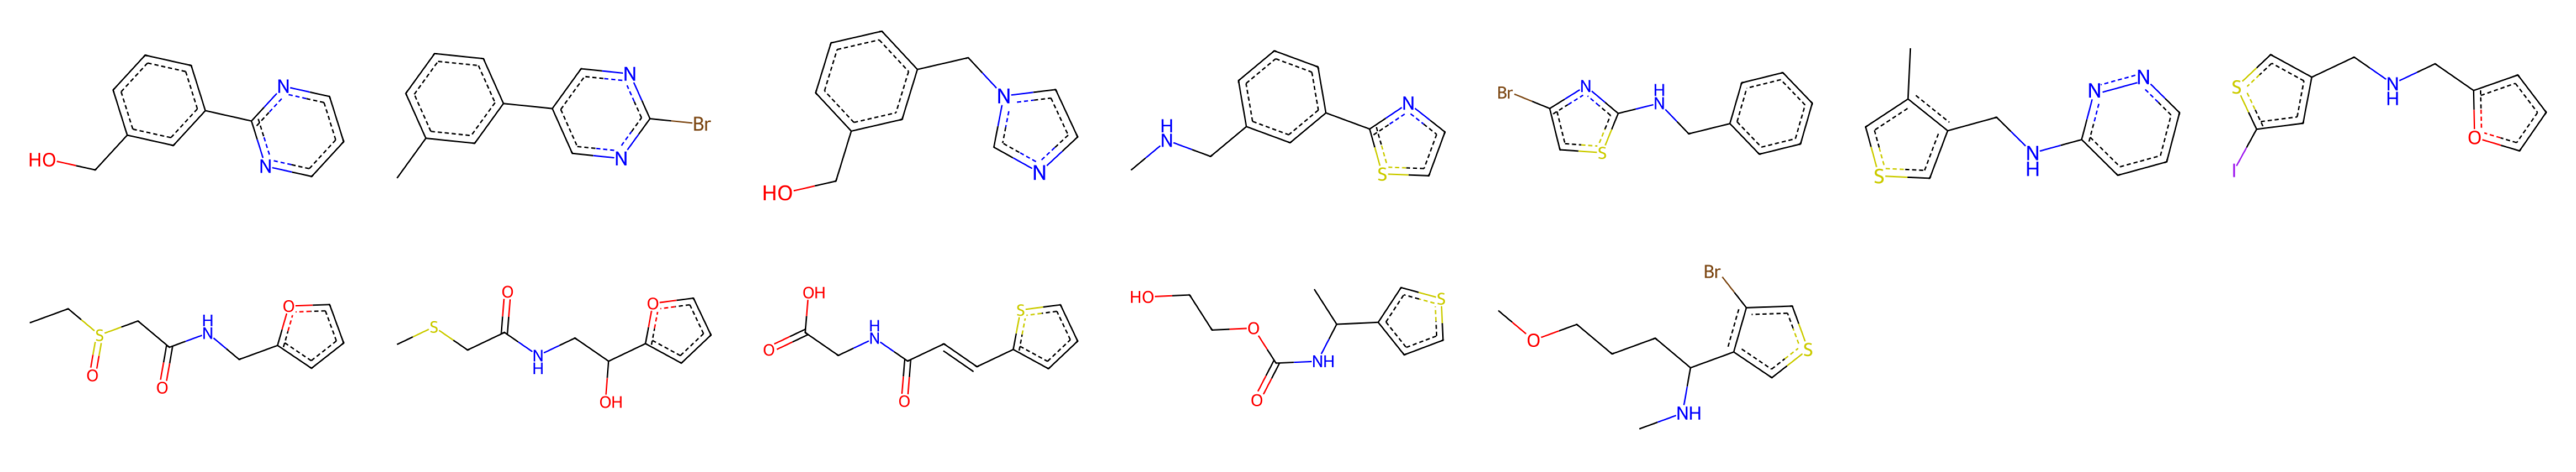

[pair] training_set_indices=[32, 35, 55, 58, 113, 168, 190, 234, 235, 240, 250, 265, 272, 290, 371, 405, 496, 510, 516, 593, 594, 621, 631, 663, 676, 702, 714, 772, 840, 841, 932, 935, 965, 984, 989, 999]


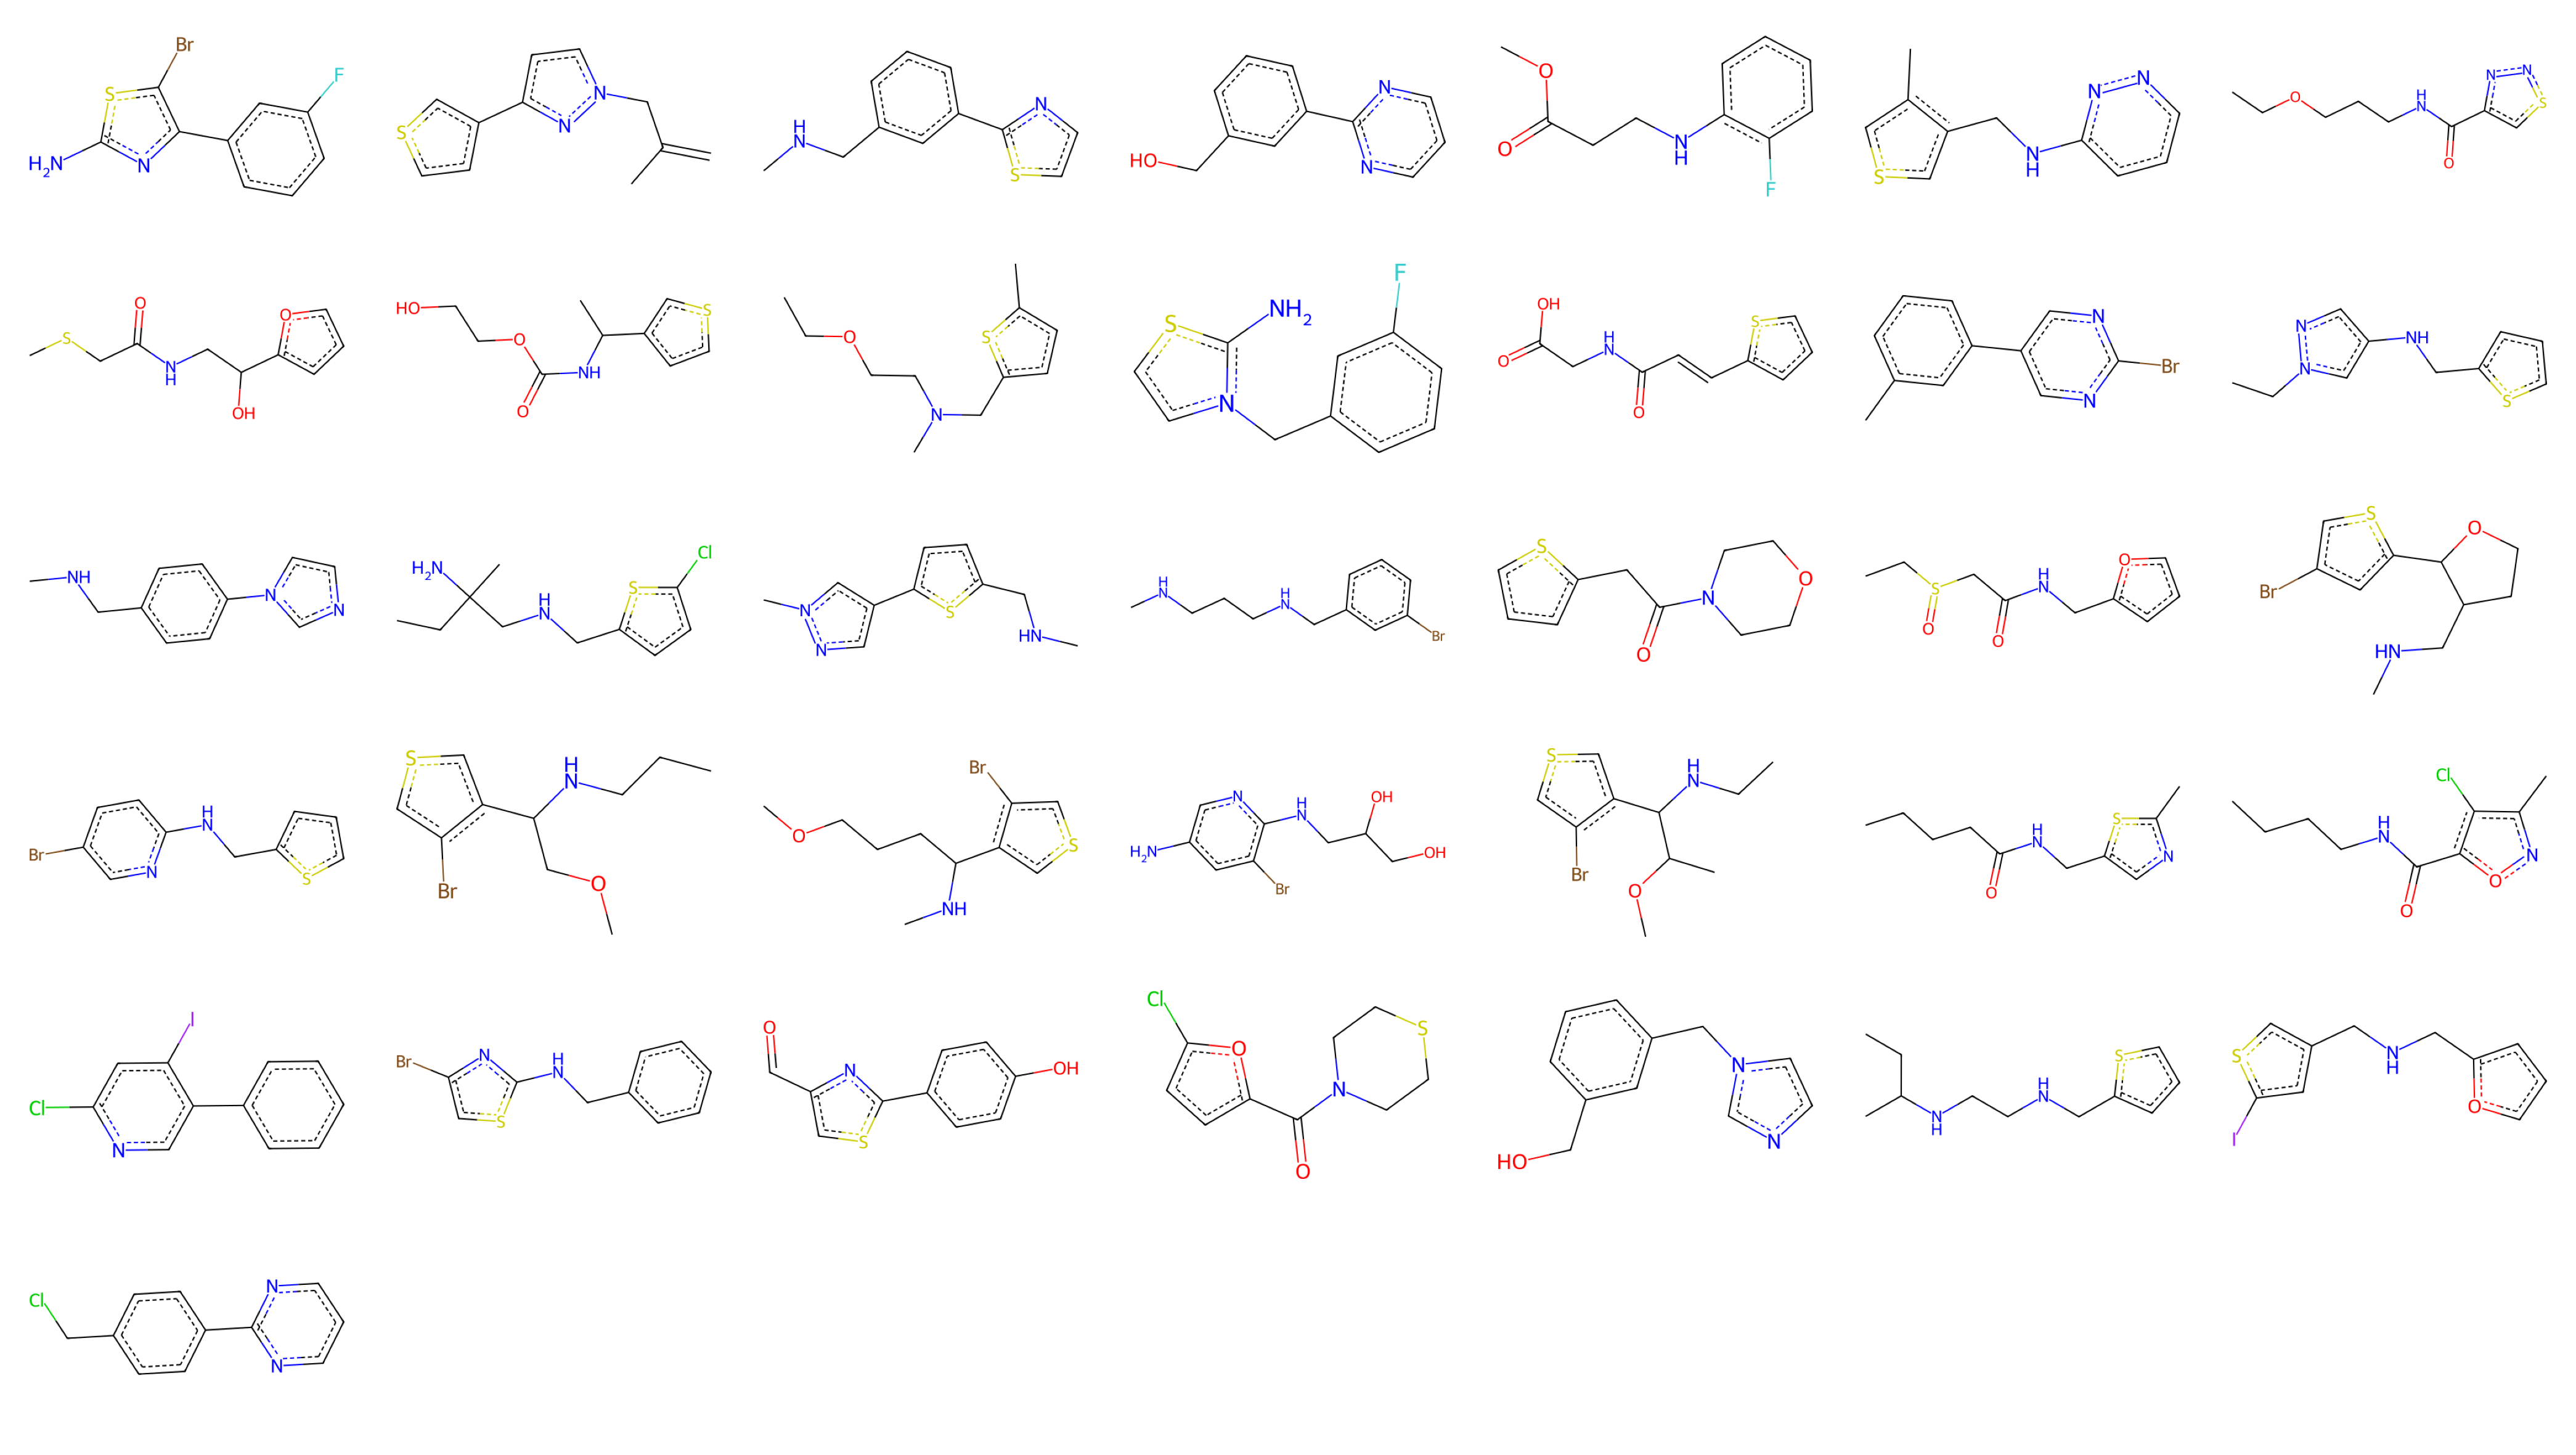

[fit] partial_feasibility_graphs=2038 final_feasibility_graphs=36 positives=2620 negatives=12200 dataset=14820 partial_time=0m 6.4s final_time=0m 0.4s
[fit] graph_estimator_graphs=14820 positive_labels=2620 negative_labels=12200 time=0m 21.4s
[graph 0] start start_edges=6 target_edges=14 remaining_edges=8


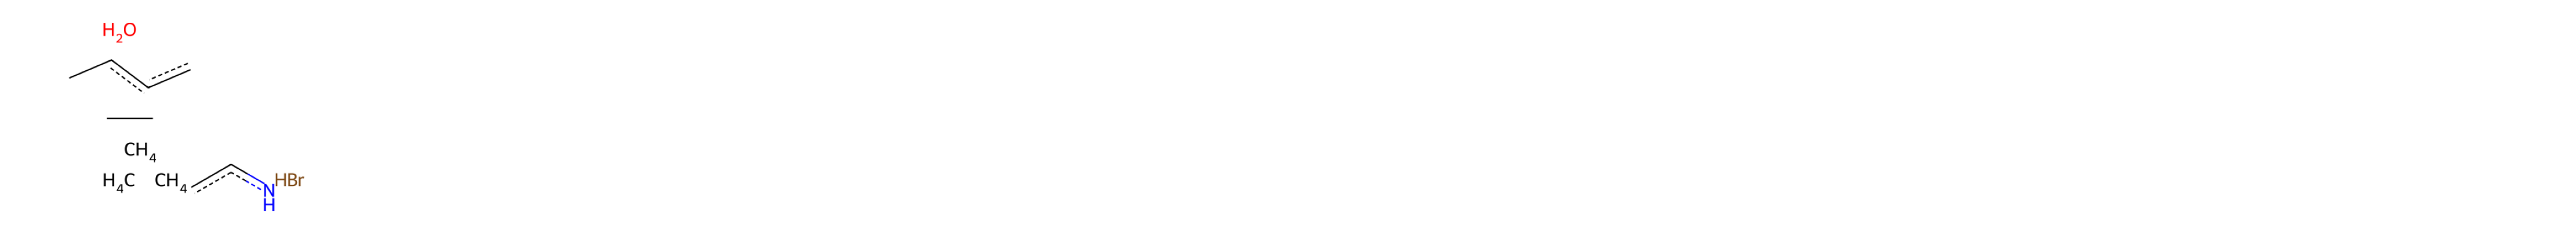

[graph 0] phase=1/5 beam_limit=2 fallback=0/4
[graph 0] phase=1/5 depth=1 remaining_edges=7 step_time=0m 6.0s eta=0m 41.8s
generated=255 feasible=134 retained=2 tried=255
best_score=1.000 best_risk=1.555
edge_risk_lambda=0.250 beam_limit=2


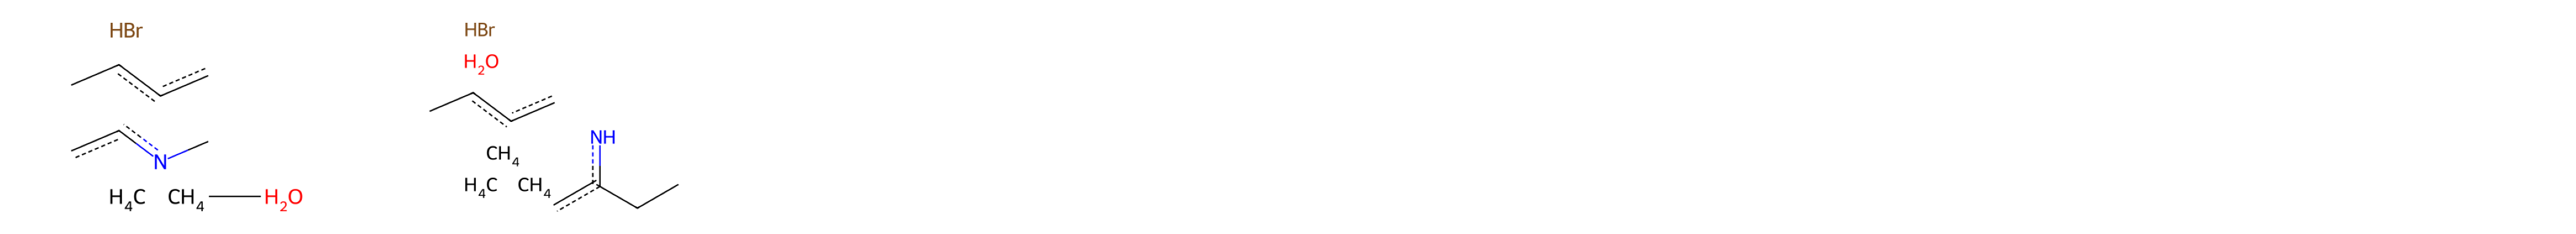

[graph 0] phase=1/5 depth=2 remaining_edges=6 step_time=0m 9.5s eta=0m 56.9s
generated=504 feasible=223 retained=2 tried=759
best_score=0.993 best_risk=0.825
edge_risk_lambda=0.250 beam_limit=2


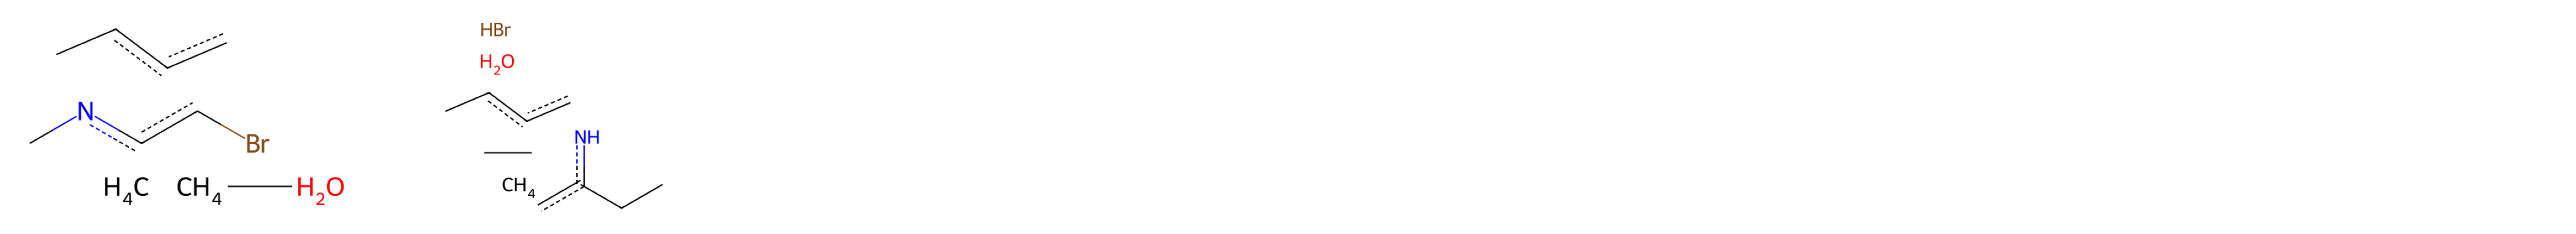

[graph 0] phase=1/5 depth=3 remaining_edges=5 step_time=0m 9.0s eta=0m 45.1s
generated=498 feasible=203 retained=2 tried=1257
best_score=0.979 best_risk=0.892
edge_risk_lambda=0.250 beam_limit=2


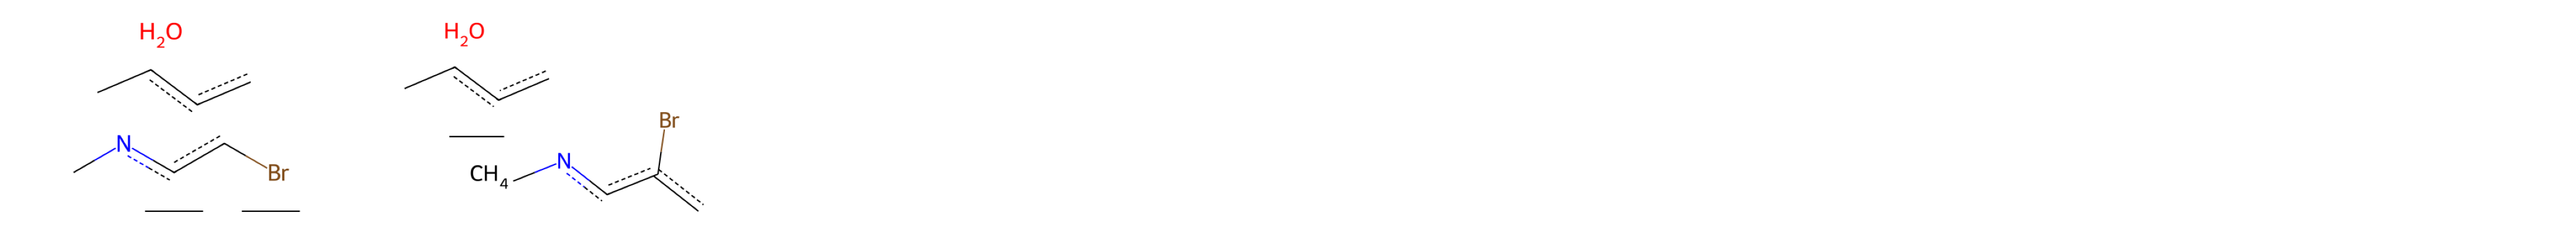

[graph 0] phase=1/5 depth=4 remaining_edges=4 step_time=0m 9.4s eta=0m 37.8s
generated=492 feasible=179 retained=2 tried=1749
best_score=0.994 best_risk=2.197
edge_risk_lambda=0.250 beam_limit=2


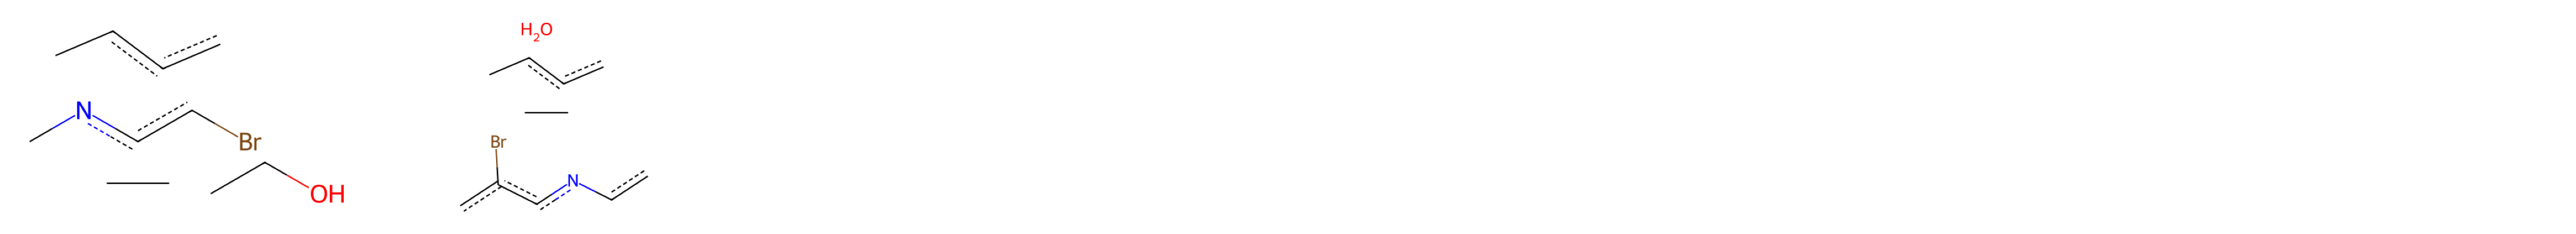

[graph 0] phase=1/5 depth=5 remaining_edges=3 step_time=0m 9.8s eta=0m 29.3s
generated=486 feasible=136 retained=2 tried=2235
best_score=0.999 best_risk=5.752
edge_risk_lambda=0.250 beam_limit=2


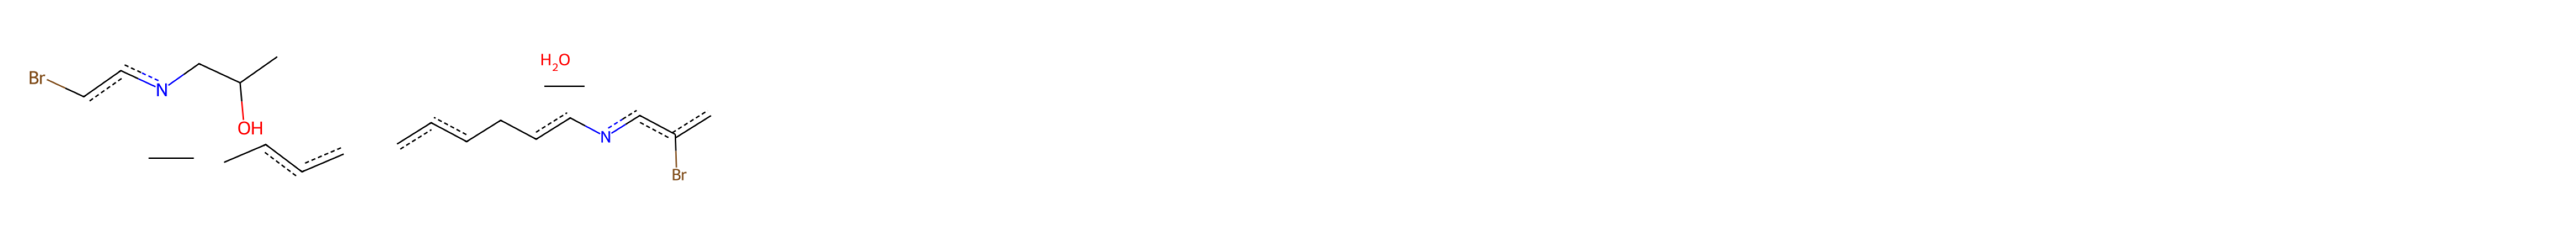

[graph 0] phase=1/5 depth=6 remaining_edges=2 step_time=0m 10.9s eta=0m 21.8s
generated=480 feasible=90 retained=2 tried=2715
best_score=0.977 best_risk=10.480
edge_risk_lambda=0.250 beam_limit=2


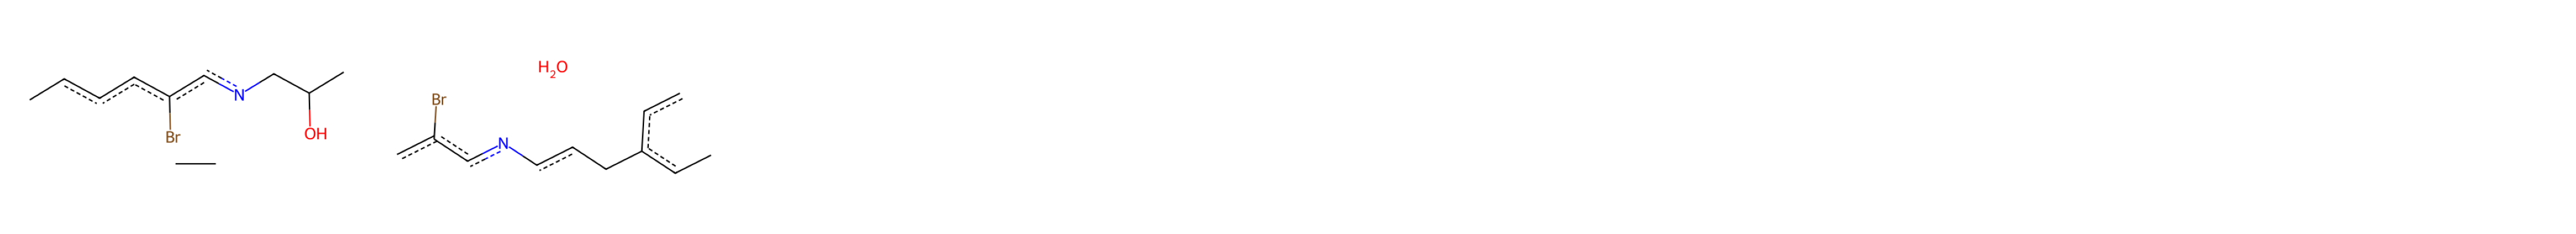

[graph 0] phase=1/5 depth=7 remaining_edges=1 step_time=0m 12.4s eta=0m 12.4s
generated=474 feasible=38 retained=2 tried=3189
best_score=0.996 best_risk=16.059
edge_risk_lambda=0.250 beam_limit=2


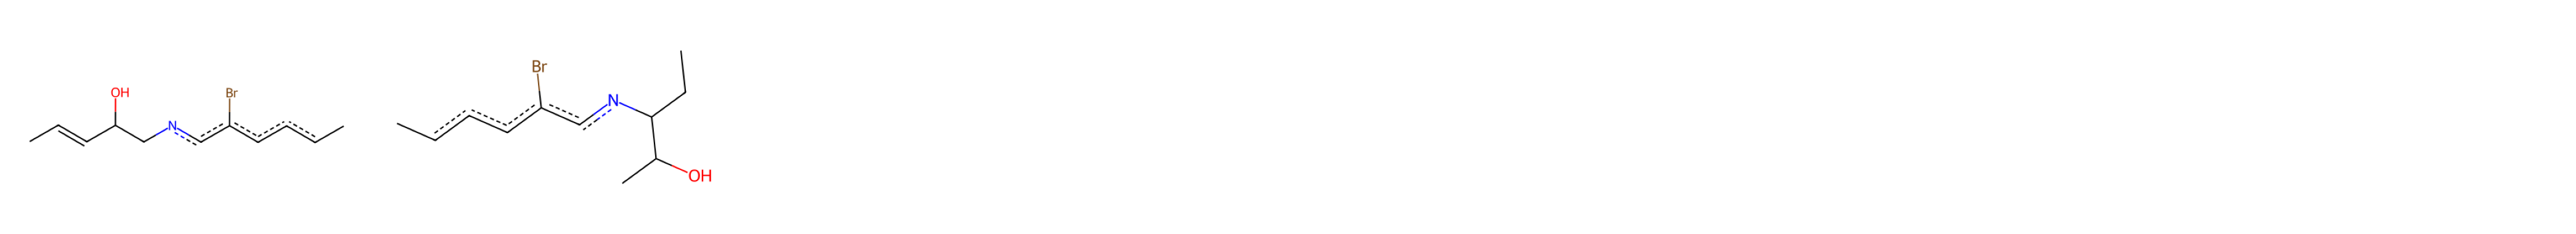

[graph 0] phase=1/5 depth=8 remaining_edges=0 step_time=0m 13.6s eta=0m 0.0s
generated=468 feasible=1 retained=1 tried=3657
best_score=0.000 best_risk=25.252
edge_risk_lambda=0.250 beam_limit=2


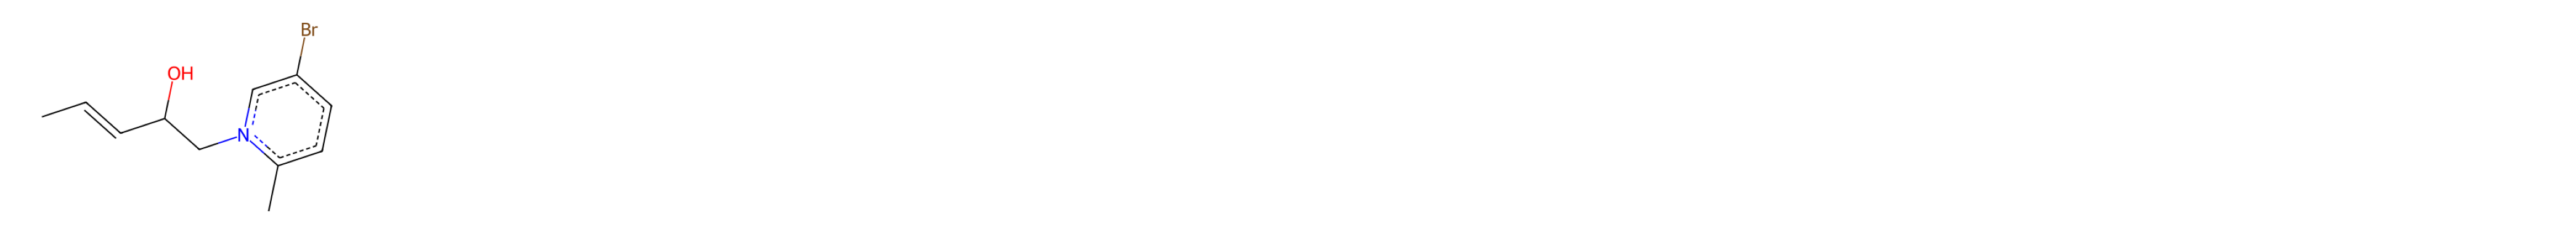

[graph 0] solved phase=1/5 depth=8 max_depth=8 edges=14 edge_shortfall=0 remaining_edges=0 tried=3657 elapsed=1m 23.0s eta=0m 0.0s
generation_path_length = 9
final_n_edges = 14


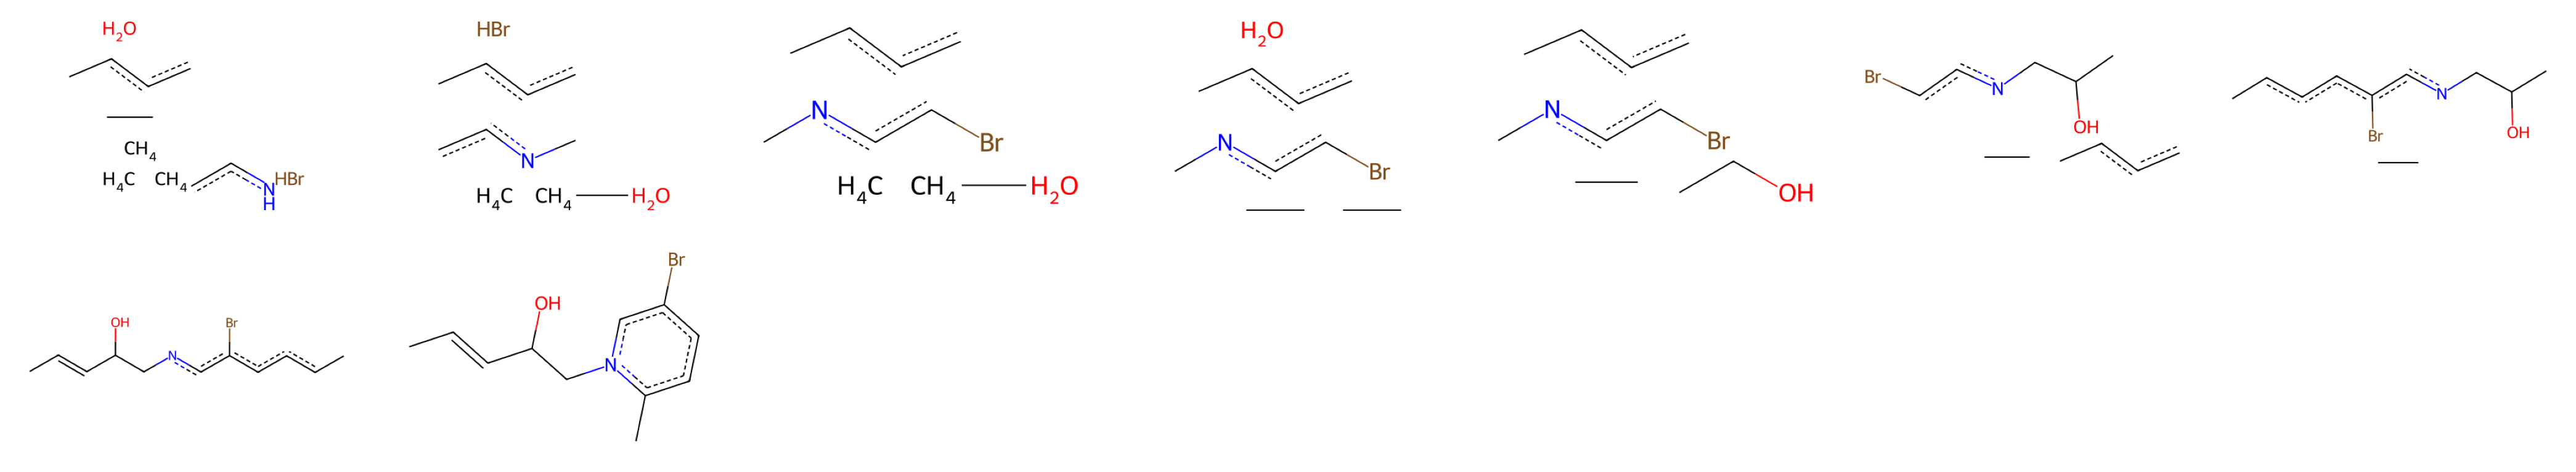

Generated graph:


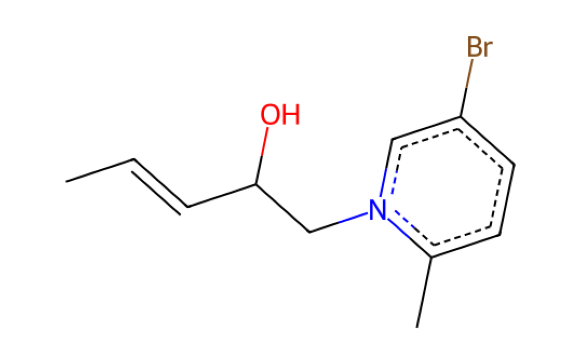

Original graphs:


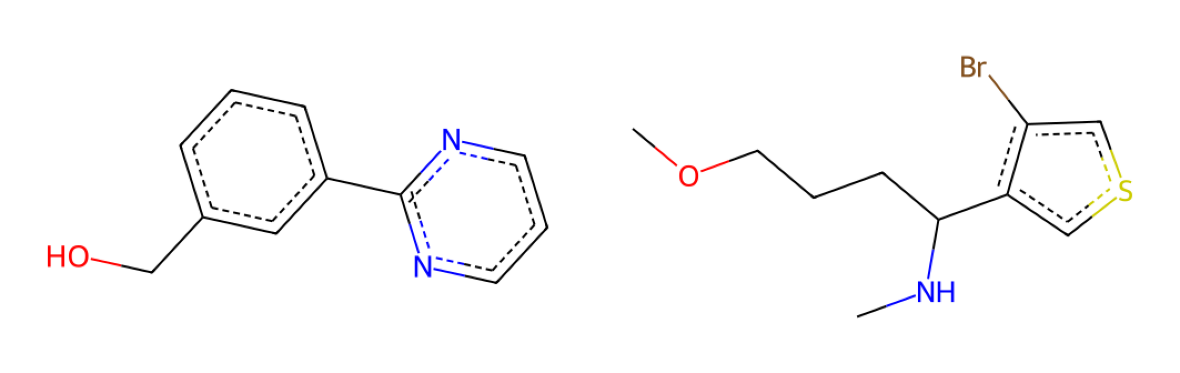

CPU times: user 1min 12s, sys: 26.6 s, total: 1min 38s
Wall time: 2min 7s


In [12]:
%%time
generation_path = generator.generate_from_pair(
    graph_a,
    graph_b,
    size_of_edge_removal=0.75,
    n_paths=2,
    path_k=7,
    n_neighbors_per_path_graph=1,
    target=pair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=7, **kwargs),
)

print(f"generation_path_length = {len(generation_path)}")
if len(generation_path) > 0 : 
    print(f"final_n_edges = {generation_path[-1].number_of_edges()}")
    display_graphs(generation_path, n_graphs_per_line=7)
    print('Generated graph:')
    display_graphs([generation_path[-1]], n_graphs_per_line=1)
    print('Original graphs:')
    display_graphs([graph_a, graph_b], n_graphs_per_line=2)

[pair] reusing cached pair session and fitted estimators
[graph 0] start start_edges=0 target_edges=14 remaining_edges=14


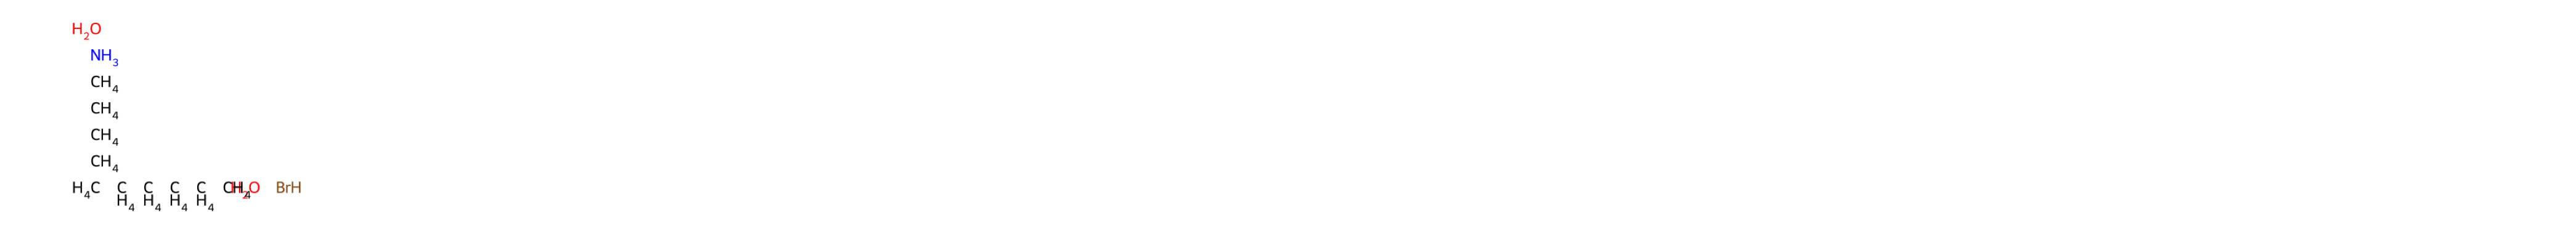

[graph 0] phase=1/5 beam_limit=2 fallback=0/4
[graph 0] phase=1/5 depth=1 remaining_edges=13 step_time=0m 9.6s eta=2m 4.9s
generated=273 feasible=227 retained=2 tried=273
best_score=1.000 best_risk=-2.415
edge_risk_lambda=0.250 beam_limit=2


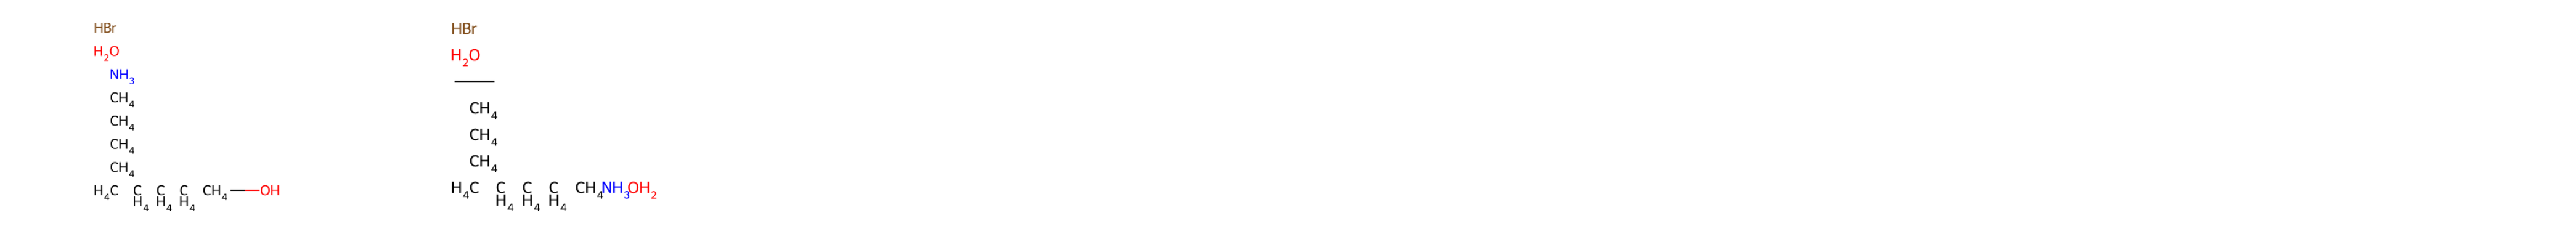

[graph 0] phase=1/5 depth=2 remaining_edges=12 step_time=0m 13.0s eta=2m 36.1s
generated=540 feasible=414 retained=2 tried=813
best_score=0.999 best_risk=-3.381
edge_risk_lambda=0.250 beam_limit=2


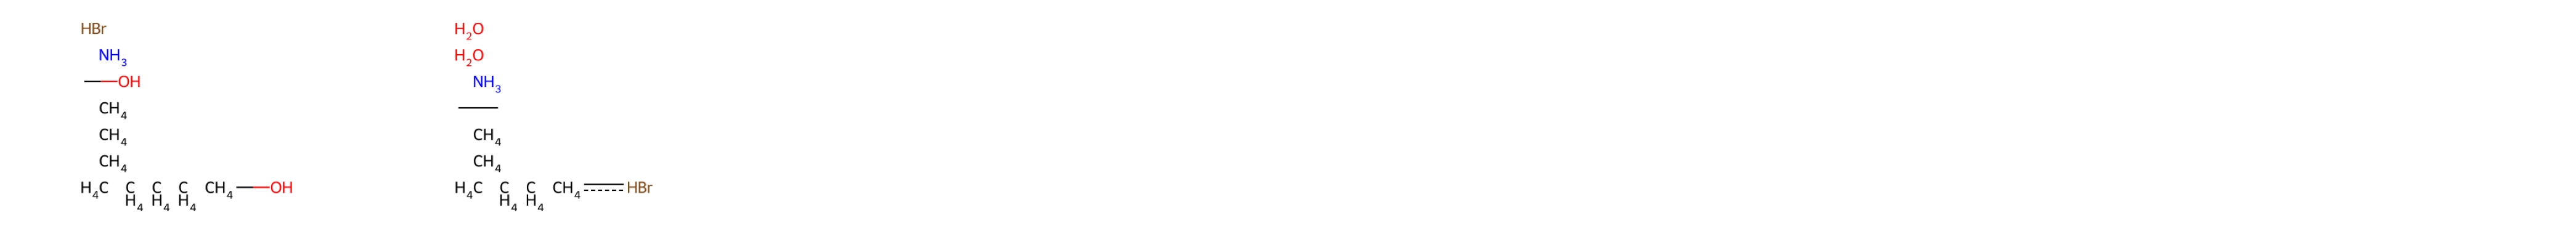

[graph 0] phase=1/5 depth=3 remaining_edges=11 step_time=0m 13.5s eta=2m 28.9s
generated=534 feasible=359 retained=2 tried=1347
best_score=0.992 best_risk=-4.042
edge_risk_lambda=0.250 beam_limit=2


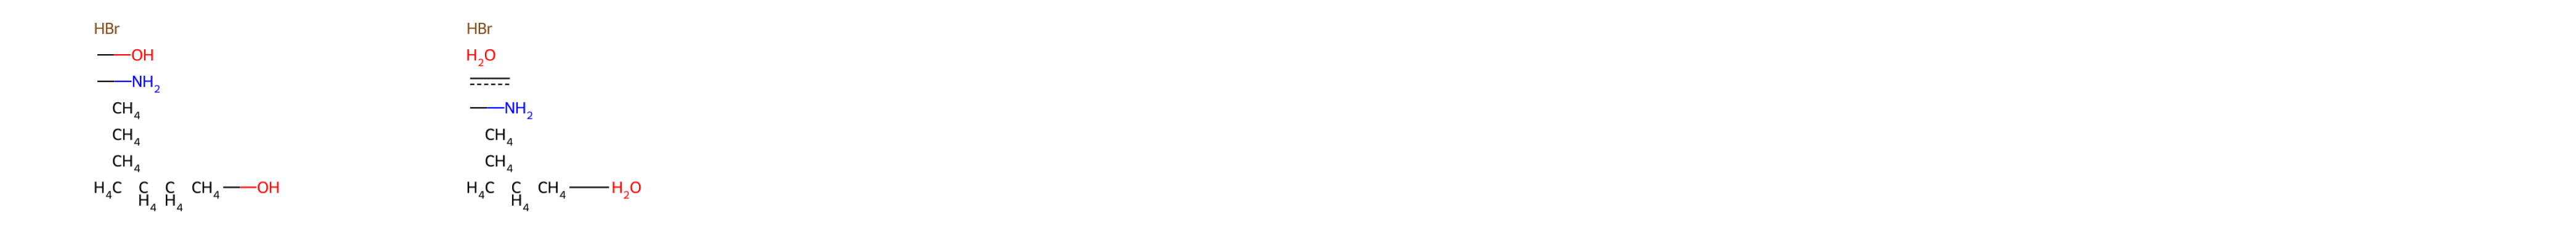

In [ ]:
%%time
generation_path = generator.generate_from_pair(
    size_of_edge_removal=.99,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=7, **kwargs),
)

print(f"generation_path_length = {len(generation_path)}")
if len(generation_path) > 0 : 
    print(f"final_n_edges = {generation_path[-1].number_of_edges()}")
    display_graphs(generation_path, n_graphs_per_line=7)
    print('Generated graph:')
    display_graphs([generation_path[-1]], n_graphs_per_line=1)
    print('Original graphs:')
    display_graphs([graph_a, graph_b], n_graphs_per_line=2)

---